# 12 Enzyme-Polymer Stable Analysis

Analyse one enzyme-polymer GROMACS production run using only Total Energy, protein backbone RMSD, and polymer RMSD relative to the protein.

## 1. Title and purpose

This notebook is intended for a single completed GROMACS production run. It contains only:

1. Total Energy as a diagnostic for abnormal drift or jumps.
2. Protein backbone RMSD after protein-backbone alignment.
3. Polymer heavy-atom RMSD after protein-backbone alignment.

## 2. Path configuration

In [1]:
from pathlib import Path
import shutil
import subprocess

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from iphasimulator.naming import oligomer_name

POLYMER_SYSTEM = oligomer_name("3HO", 4)
SYSTEM_NAME = f"GK13_{POLYMER_SYSTEM}"
SYSTEM_DIR = Path("/Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme") / f"{SYSTEM_NAME}_gromacs"

XTC_PATH = SYSTEM_DIR / "production_combined_003.xtc"
EDR_PATH = SYSTEM_DIR / "production_combined_003.edr"
GRO_PATH = SYSTEM_DIR / "step6.2_npt.gro"
TPR_PATH = SYSTEM_DIR / "step6.2_npt.tpr"

OUTPUT_DIR = SYSTEM_DIR / "analysis" / "enzyme_polymer_stable_analysis"

POLYMER_SELECTION = "resname LIG"

paths = {
    "system_dir": SYSTEM_DIR,
    "trajectory_xtc": XTC_PATH,
    "energy_edr": EDR_PATH,
    "structure_gro": GRO_PATH,
    "topology_tpr": TPR_PATH,
    "output_dir": OUTPUT_DIR,
}

for label, path in paths.items():
    print(f"{label:16s} {path}")

system_dir       /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/GK13_P3HO_4_gromacs
trajectory_xtc   /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/GK13_P3HO_4_gromacs/production_combined_003.xtc
energy_edr       /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/GK13_P3HO_4_gromacs/production_combined_003.edr
structure_gro    /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/GK13_P3HO_4_gromacs/step6.2_npt.gro
topology_tpr     /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/GK13_P3HO_4_gromacs/step6.2_npt.tpr
output_dir       /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/GK13_P3HO_4_gromacs/analysis/enzyme_polymer_stable_analysis


## 3. File checks

In [2]:
required_files = {
    "XTC_PATH": XTC_PATH,
    "EDR_PATH": EDR_PATH,
    "GRO_PATH": GRO_PATH,
}

file_check = pd.DataFrame(
    [
        {"label": label, "path": str(path), "exists": path.exists()}
        for label, path in {**required_files, "TPR_PATH": TPR_PATH}.items()
    ]
)
display(file_check)

missing = [f"{label}: {path}" for label, path in required_files.items() if not path.exists()]
if missing:
    raise FileNotFoundError("Missing required input file(s):\n" + "\n".join(missing))

if not TPR_PATH.exists():
    print(f"TPR_PATH was not found. MDAnalysis will use GRO_PATH as the topology: {GRO_PATH}")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Output directory: {OUTPUT_DIR}")

,label,path,exists
0,XTC_PATH,/Users/k20098771/Data/MD_projects/PHA/MD_data/...,True
1,EDR_PATH,/Users/k20098771/Data/MD_projects/PHA/MD_data/...,True
2,GRO_PATH,/Users/k20098771/Data/MD_projects/PHA/MD_data/...,True
3,TPR_PATH,/Users/k20098771/Data/MD_projects/PHA/MD_data/...,True


Output directory: /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/GK13_P3HO_4_gromacs/analysis/enzyme_polymer_stable_analysis


## 4. Total Energy diagnostic

Total Energy is only a first diagnostic. In NVT/NPT, it is not expected to be perfectly conserved, but strong drift or sudden jumps suggest a problem. The plot overlays a cumulative frame mean: at each frame, the mean includes all energy values from the first frame through the current frame.

The extraction uses GROMACS `gmx energy` and selects only Total Energy. The notebook first tries `Total-Energy`, then retries with `Total Energy` if needed. GROMACS reports the energy time in picoseconds; the notebook converts it to nanoseconds for plotting and CSV export.

Equivalent shell command for the first attempt:

```bash
printf "Total-Energy\n0\n" | gmx energy -f production_combined_003.edr -o total_energy.xvg
```

In [3]:
TOTAL_ENERGY_XVG = OUTPUT_DIR / "total_energy.xvg"
TOTAL_ENERGY_CSV = OUTPUT_DIR / "total_energy.csv"
TOTAL_ENERGY_PNG = OUTPUT_DIR / "total_energy.png"

GMX_EXECUTABLE = shutil.which("gmx") or shutil.which("gmx_mpi")
if GMX_EXECUTABLE is None:
    raise RuntimeError("Could not find `gmx` or `gmx_mpi` on PATH. Load GROMACS before running this cell.")
if not EDR_PATH.exists():
    raise FileNotFoundError(f"Energy file does not exist: {EDR_PATH}")
if EDR_PATH.suffix.lower() != ".edr":
    raise ValueError(f"EDR_PATH must point to a .edr file, not: {EDR_PATH}")

print(f"GROMACS executable: {GMX_EXECUTABLE}")
print(f"Energy input: {EDR_PATH.resolve()}")


def run_gmx_energy(selection_name: str) -> subprocess.CompletedProcess:
    if TOTAL_ENERGY_XVG.exists():
        TOTAL_ENERGY_XVG.unlink()

    command = [
        GMX_EXECUTABLE,
        "energy",
        "-f",
        str(EDR_PATH),
        "-o",
        str(TOTAL_ENERGY_XVG),
    ]
    return subprocess.run(
        command,
        input=f"{selection_name}\n0\n",
        text=True,
        capture_output=True,
        cwd=OUTPUT_DIR,
        check=False,
    )


attempts = []
energy_selection = None
for candidate in ("Total-Energy", "Total Energy"):
    result = run_gmx_energy(candidate)
    attempts.append((candidate, result.returncode, result.stdout, result.stderr))
    if result.returncode == 0 and TOTAL_ENERGY_XVG.exists() and TOTAL_ENERGY_XVG.stat().st_size > 0:
        energy_selection = candidate
        break

if energy_selection is None:
    details = []
    for candidate, returncode, stdout, stderr in attempts:
        details.append(
            f"Selection: {candidate}\n"
            f"Return code: {returncode}\n"
            f"STDOUT:\n{stdout}\n"
            f"STDERR:\n{stderr}"
        )
    raise RuntimeError("gmx energy failed for both Total-Energy and Total Energy.\n\n" + "\n\n".join(details))

print(f"Extracted GROMACS energy term: {energy_selection}")
print(f"Wrote: {TOTAL_ENERGY_XVG}")


def read_xvg_two_column(path: Path) -> pd.DataFrame:
    rows = []
    with path.open() as handle:
        for line in handle:
            stripped = line.strip()
            if not stripped or stripped.startswith(("#", "@")):
                continue
            parts = stripped.split()
            if len(parts) < 2:
                continue
            rows.append((float(parts[0]), float(parts[1])))
    if not rows:
        raise ValueError(f"No numeric two-column data were found in {path}")
    return pd.DataFrame(rows, columns=["time_ps", "total_energy"])


energy_df = read_xvg_two_column(TOTAL_ENERGY_XVG)
energy_df["time_ns"] = energy_df["time_ps"] / 1000.0
energy_df["cumulative_mean_energy"] = energy_df["total_energy"].expanding(min_periods=1).mean()
energy_df.to_csv(TOTAL_ENERGY_CSV, index=False)

print(f"Energy samples: {len(energy_df)}")
print(f"Energy time range: {energy_df['time_ns'].iloc[0]:.3f} to {energy_df['time_ns'].iloc[-1]:.3f} ns")

GROMACS executable: /opt/homebrew/bin/gmx
Energy input: /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/GK13_P3HO_4_gromacs/production_combined_003.edr
Extracted GROMACS energy term: Total-Energy
Wrote: /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/GK13_P3HO_4_gromacs/analysis/enzyme_polymer_stable_analysis/total_energy.xvg
Energy samples: 357998
Energy time range: 0.000 to 715.994 ns


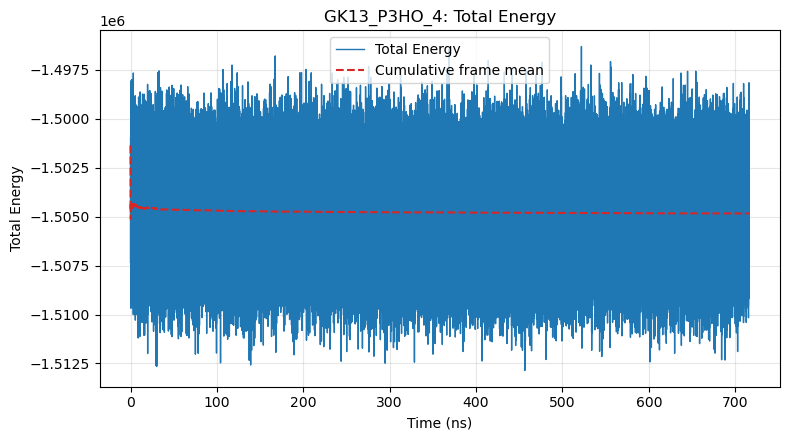

Wrote: /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/GK13_P3HO_4_gromacs/analysis/enzyme_polymer_stable_analysis/total_energy.csv
Wrote: /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/GK13_P3HO_4_gromacs/analysis/enzyme_polymer_stable_analysis/total_energy.png


In [4]:
# plot
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(energy_df["time_ns"], energy_df["total_energy"], linewidth=1.0, label="Total Energy")
ax.plot(energy_df["time_ns"], energy_df["cumulative_mean_energy"], color="tab:red", linestyle="--", linewidth=1.5, label="Cumulative frame mean")
ax.set_xlabel("Time (ns)")
ax.set_ylabel("Total Energy")
ax.set_title(f"{SYSTEM_NAME}: Total Energy")
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(TOTAL_ENERGY_PNG, dpi=400)
plt.show()

print(f"Wrote: {TOTAL_ENERGY_CSV}")
print(f"Wrote: {TOTAL_ENERGY_PNG}")

In [5]:
# Load the trajectory

try:
    import MDAnalysis as mda
except ImportError as exc:
    raise ImportError("MDAnalysis is required for the RMSD analyses. Install or load it before running this notebook.") from exc

def load_universe_with_fallback():
    attempts = []
    for topology_path in (TPR_PATH, GRO_PATH):
        if not topology_path.exists():
            attempts.append(f"{topology_path}: file does not exist")
            continue
        try:
            universe = mda.Universe(str(topology_path), str(XTC_PATH))
            return universe, topology_path
        except Exception as exc:
            attempts.append(f"{topology_path}: {type(exc).__name__}: {exc}")
    raise RuntimeError("MDAnalysis could not load the trajectory with TPR_PATH or GRO_PATH.\n" + "\n".join(attempts))


u, topology_used = load_universe_with_fallback()
print(f"Loaded topology: {topology_used}")
print(f"Loaded trajectory: {XTC_PATH}")
print(f"Atoms: {u.atoms.n_atoms}")
print(f"Frames: {len(u.trajectory)}")

/opt/homebrew/Caskroom/miniconda/base/envs/ipha_clean/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded topology: /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/GK13_P3HO_4_gromacs/step6.2_npt.tpr
Loaded trajectory: /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/GK13_P3HO_4_gromacs/production_combined_003.xtc
Atoms: 137360
Frames: 7160


## 5. RMSD analyses

Use protein backbone RMSD as the primary global-stability measurement and protein-aligned polymer RMSD to assess polymer motion relative to the enzyme. Total Energy is retained only as a diagnostic for abnormal drift or simulation problems.

Inspect the plots and compact final-20% statistics manually. The notebook does not automatically decide whether the trajectory must be extended.

### 5.1 RMSD selections and shared helpers

The protein-aligned measurements use only protein backbone atoms named N, CA, and C for alignment. Polymer RMSD uses LIG heavy atoms and does not align the polymer separately.

In [6]:
from MDAnalysis.analysis import align, rms

PROTEIN_BACKBONE_SELECTION = "protein and name N CA C"
POLYMER_HEAVY_SELECTION = f"({POLYMER_SELECTION}) and not name H*"
RMSD_ROLLING_WINDOW_FRAMES = 100  # Set to None to disable the optional rolling mean.

protein_backbone = u.select_atoms(PROTEIN_BACKBONE_SELECTION)
polymer_heavy_atoms = u.select_atoms(POLYMER_HEAVY_SELECTION)

for selection_label, atom_group in {
    "protein backbone (N, CA, C)": protein_backbone,
    "polymer heavy atoms": polymer_heavy_atoms,
}.items():
    print(f"{selection_label}: {atom_group.n_atoms} atoms selected")
    if atom_group.n_atoms == 0:
        raise ValueError(f"The {selection_label!r} selection contains no atoms.")

reference_u, reference_topology_used = load_universe_with_fallback()
reference_u.trajectory[0]
reference_backbone = reference_u.select_atoms(PROTEIN_BACKBONE_SELECTION)
reference_polymer_heavy = reference_u.select_atoms(POLYMER_HEAVY_SELECTION)

if reference_backbone.n_atoms != protein_backbone.n_atoms:
    raise ValueError("Mobile and reference protein-backbone selections contain different atom counts.")
if reference_polymer_heavy.n_atoms != polymer_heavy_atoms.n_atoms:
    raise ValueError("Mobile and reference polymer-heavy-atom selections contain different atom counts.")

print(f"Reference topology: {reference_topology_used}")
print(f"Reference frame: {reference_u.trajectory.frame}")


def trajectory_row(ts, value_column: str, value: float) -> dict:
    time_ps = float(ts.time)
    return {
        "frame": int(ts.frame),
        "time_ps": time_ps,
        "time_ns": time_ps / 1000.0,
        value_column: float(value),
    }


def compact_rmsd_statistics(values) -> dict:
    series = pd.Series(values, dtype=float).dropna().reset_index(drop=True)
    if series.empty:
        raise ValueError("Cannot summarise an empty RMSD series.")
    final_count = max(1, int(np.ceil(0.20 * len(series))))
    final_window = series.iloc[-final_count:]
    return {
        "mean_A": float(series.mean()),
        "std_A": float(series.std(ddof=1)),
        "final_20_percent_mean_A": float(final_window.mean()),
        "final_20_percent_std_A": float(final_window.std(ddof=1)),
    }


def save_rmsd_outputs(
    metric_df,
    value_column: str,
    csv_path: Path,
    png_path: Path,
    ylabel: str,
    title: str,
    rolling_window_frames: int | None = None,
):
    if metric_df.empty:
        raise ValueError(f"No values were calculated for {value_column}.")
    values = metric_df[value_column].to_numpy(dtype=float)
    if not np.all(np.isfinite(values)):
        raise ValueError(f"Non-finite values were calculated for {value_column}.")

    plot_df = metric_df.copy()
    rolling_column = None
    if rolling_window_frames is not None:
        if rolling_window_frames < 1:
            raise ValueError("rolling_window_frames must be at least 1 or None.")
        rolling_column = f"{value_column}_rolling_mean"
        plot_df[rolling_column] = plot_df[value_column].rolling(
            rolling_window_frames, min_periods=1
        ).mean()

    plot_df.to_csv(csv_path, index=False)
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(plot_df["time_ns"], plot_df[value_column], linewidth=0.8, alpha=0.55, label="Raw RMSD")
    if rolling_column is not None:
        ax.plot(
            plot_df["time_ns"],
            plot_df[rolling_column],
            linewidth=1.8,
            label=f"Rolling mean ({rolling_window_frames} frames)",
        )
    ax.set_xlabel("Time (ns)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend()
    fig.tight_layout()
    fig.savefig(png_path, dpi=400)
    plt.show()

    stats = compact_rmsd_statistics(plot_df[value_column])
    print(f"Mean RMSD: {stats['mean_A']:.4f} Å")
    print(f"RMSD standard deviation: {stats['std_A']:.4f} Å")
    print(f"Final 20% mean RMSD: {stats['final_20_percent_mean_A']:.4f} Å")
    print(f"Final 20% RMSD standard deviation: {stats['final_20_percent_std_A']:.4f} Å")
    print(f"Wrote: {csv_path}")
    print(f"Wrote: {png_path}")
    return stats

protein backbone (N, CA, C): 735 atoms selected
polymer heavy atoms: 41 atoms selected
Reference topology: /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/GK13_P3HO_4_gromacs/step6.2_npt.tpr
Reference frame: 0


### 5.2 Protein backbone RMSD

Each frame is aligned to the first trajectory frame using protein backbone atoms N, CA, and C. The reported backbone RMSD therefore measures protein structural deviation after removing overall translation and rotation.

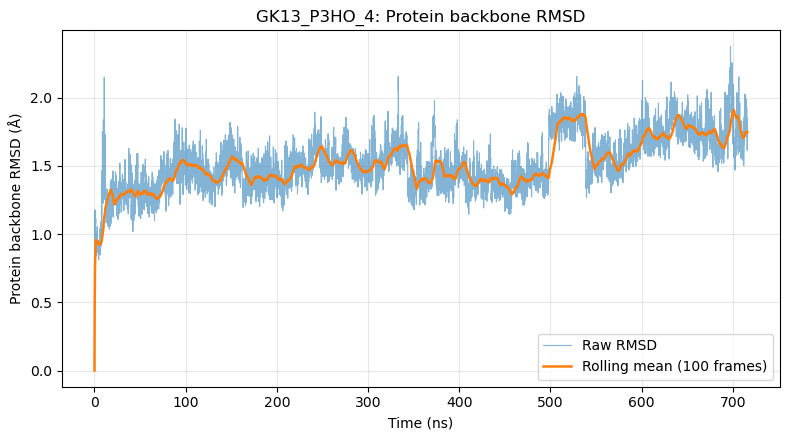

Mean RMSD: 1.5205 Å
RMSD standard deviation: 0.1997 Å
Final 20% mean RMSD: 1.7293 Å
Final 20% RMSD standard deviation: 0.1356 Å
Wrote: /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/GK13_P3HO_4_gromacs/analysis/enzyme_polymer_stable_analysis/protein_backbone_rmsd.csv
Wrote: /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/GK13_P3HO_4_gromacs/analysis/enzyme_polymer_stable_analysis/protein_backbone_rmsd.png


In [7]:
PROTEIN_BACKBONE_RMSD_CSV = OUTPUT_DIR / "protein_backbone_rmsd.csv"
PROTEIN_BACKBONE_RMSD_PNG = OUTPUT_DIR / "protein_backbone_rmsd.png"

protein_backbone_rmsd_rows = []
reference_u.trajectory[0]
for ts in u.trajectory:
    align.alignto(u, reference_u, select=PROTEIN_BACKBONE_SELECTION, weights=None)
    backbone_rmsd_A = rms.rmsd(
        protein_backbone.positions,
        reference_backbone.positions,
        center=False,
        superposition=False,
    )
    protein_backbone_rmsd_rows.append(trajectory_row(ts, "protein_backbone_rmsd_A", backbone_rmsd_A))

protein_backbone_rmsd_df = pd.DataFrame(protein_backbone_rmsd_rows)
protein_backbone_rmsd_stats = save_rmsd_outputs(
    protein_backbone_rmsd_df,
    "protein_backbone_rmsd_A",
    PROTEIN_BACKBONE_RMSD_CSV,
    PROTEIN_BACKBONE_RMSD_PNG,
    "Protein backbone RMSD (Å)",
    f"{SYSTEM_NAME}: Protein backbone RMSD",
    rolling_window_frames=RMSD_ROLLING_WINDOW_FRAMES,
)

### 5.3 Polymer RMSD relative to the protein

Every trajectory frame is first aligned to the first frame using the protein backbone. Polymer heavy-atom RMSD is then calculated without any separate polymer alignment. This measures whether the polymer remains in a similar position and orientation relative to the enzyme.

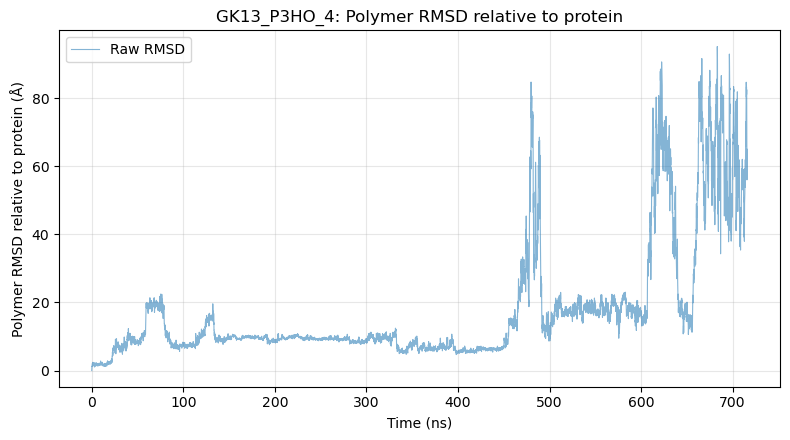

Mean RMSD: 17.8797 Å
RMSD standard deviation: 18.3752 Å
Final 20% mean RMSD: 44.0480 Å
Final 20% RMSD standard deviation: 23.6803 Å
Wrote: /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/GK13_P3HO_4_gromacs/analysis/enzyme_polymer_stable_analysis/polymer_rmsd_relative_to_protein.csv
Wrote: /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/GK13_P3HO_4_gromacs/analysis/enzyme_polymer_stable_analysis/polymer_rmsd_relative_to_protein.png


In [8]:
POLYMER_RELATIVE_RMSD_CSV = OUTPUT_DIR / "polymer_rmsd_relative_to_protein.csv"
POLYMER_RELATIVE_RMSD_PNG = OUTPUT_DIR / "polymer_rmsd_relative_to_protein.png"

polymer_relative_rmsd_rows = []
reference_u.trajectory[0]
for ts in u.trajectory:
    align.alignto(u, reference_u, select=PROTEIN_BACKBONE_SELECTION, weights=None)
    polymer_relative_rmsd_A = rms.rmsd(
        polymer_heavy_atoms.positions,
        reference_polymer_heavy.positions,
        center=False,
        superposition=False,
    )
    polymer_relative_rmsd_rows.append(
        trajectory_row(ts, "polymer_relative_to_protein_rmsd_A", polymer_relative_rmsd_A)
    )

polymer_relative_rmsd_df = pd.DataFrame(polymer_relative_rmsd_rows)
polymer_relative_rmsd_stats = save_rmsd_outputs(
    polymer_relative_rmsd_df,
    "polymer_relative_to_protein_rmsd_A",
    POLYMER_RELATIVE_RMSD_CSV,
    POLYMER_RELATIVE_RMSD_PNG,
    "Polymer RMSD relative to protein (Å)",
    f"{SYSTEM_NAME}: Polymer RMSD relative to protein",
)